## Fairness, Accountability, Transparency and Ethics Course (FATE)
## Universitat Pompeu Fabra (UPF)
### Academic Year 2025-2026
### Author: Morgan Gallagher (morgan.gallagher@upf.edu)
*** Based on the original exercises made by Ashwin Singh (ashwin.singh@tuwien.ac.at) ***

Submission date: TBA on Aula Global

Remember to submit this notebook **individually**.

# LAB 1: Data anonymization with Python

Author: <font color="blue">Your name here</font>

E-mail: <font color="blue">Your e-mail here</font>

Date: <font color="blue">The current date here</font>

# Getting Started

## Imports

In [1]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import random

KeyboardInterrupt: 

In [ ]:
import warnings

warnings.filterwarnings(action="ignore")

## Loading Dataset

In this section we will use a synthetic dataset containing medical records of 100 users.

In [ ]:
dataset_url = "https://raw.githubusercontent.com/Ashwin-19/UPF-FATE-2025/refs/heads/main/Lab%20I%20-%20Data%20Anonymization/Data/health_dataset.csv"
health_data = pd.read_csv(dataset_url)
health_data.head()

## Types of Identifiers and Attributes **[ 1 pt ]**



Recall from slides [T04C](https://docs.google.com/presentation/d/1RuPpXZ1pp8AyOgdvYRmau6HIq0oq4SP0JR_mIglJH6c/present?slide=id.p), microdata provides information about the characteristics of individuals and entities. Four attributes are discussed.


*   **Identifiers:** Unambiguously identify a person (DNI/NIE)
*   **Quasi-identifiers:** Can identify a person when combined with other quasi-identifiers (telephone number + age)
*   **Confidential attributes:** Sensitive information about a person (gender, medical diagnosis, religion)
*   **Non-confidential attributes:** Everything else



**[ 0.5 pts ]** List the identifiers and quasi-identifiers in the medical records dataset:

**[ Wrte Answer Here]**

**[ 0.5 pts ]** List the confidential attributes in the dataset.

**[ Write Answer Here ]**

## Data Filtering **[ 0.5 pts ]**

**[ 0.25 pts ]** Remove/Suppress the columns including personally identifiable information from the dataset.

In [ ]:
""" your code here """
# pii_columns = []
# health_data = health_data[pii_columns]
# health_data.head()

**[ 0.25 pts ]** Why do we remove/supress these columns?

**[Write Answer Here]**

# K-Anonymity

Sweeney, L. (2002). k-ANONYMITY: A MODEL FOR PROTECTING PRIVACY. International Journal of Uncertainty, Fuzziness and Knowledge-Based Systems, 10(05), 557–570. https://doi.org/10.1142/S0218488502001648

1.   x1 , x2 ∈ X belong to the same equivalence class if ∀ quasi-identifiers q ∈ Q, x1(q) = x2(q).
2.   X satisfies k-anonymity when there exist at least k elements in each equivalence class.

A dataset is **k-anonymous** if there are **at least k shared quasi-identifier values** in an equivalence class.

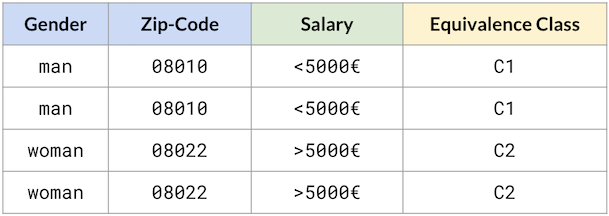

The above dataset is 2-anonymous.

## Checking K-Anonymity **[ 1 pt ]**

**[ 0.5 pts ]** Create a function which checks whether the data sastifies k-anonimity given some quasi-identifiers. Also return the maximum k for which the quasi-identifiers satisfy k-anonymity.

In [ ]:
def is_k_anonymous(data, quasi_identifiers):
    """
    Determines whether the data is k-anonymous quasi-identifiers
    and the maximum k for which k-anonymity is satisfied.

    Args:
        data (pandas.DataFrame): microdata
        quasi_identifiers (list): quasi-identifiers in microdata

    Returns:
        bool: indicating whether the data is k-anonymous
        int: maximum k for which k-anonymity is satisfied
    """
    # Your code here

**[ 0.25 pts ]** Is the data k-anonymous for BirthDate and ZipCode? If so, what is the maximum k for which k-anonymity is satisfied?

In [ ]:
# Your code here

**[ 0.25 pts ]** Is the data k-anonymous for Gender and ZipCode? If so, what is the maximum k for which k-anonymity is satisfied?

In [ ]:
# Your code here

## Testing K-Anonimity **[ 0.5 pts ]**

To test our function, we will use a dataset from the example given in the [K-Anonymity article](https://en.wikipedia.org/wiki/K-anonymity) on Wikipedia and satisfies 2-anonymity for any combination of the attributes ``Age``, ``Gender`` and ``State of domicile``.

In [ ]:
wiki_data = pd.read_html("https://en.wikipedia.org/wiki/K-anonymity", header=0, storage_options={'User-Agent': 'Mozilla/5.0'})[1]
wiki_data

**[ 0.5 pts ]** Test k-anonimity for the three attributes and their different combinations picking two attributes at a time. For each combination, find the maximum k satisfying k-anonymity.

In [ ]:
## Your code here

In [ ]:
## Your code here

In [ ]:
## Your code here

In [ ]:
## Your code here

## Properties of K-Anonymity **[ 1 pt ]**
> You may use examples from the previous exercises.

**[ 0.5 pts ]** If a dataset is $k_1$-anonymous for a set of attributes, and $k_2$-anonymous for any subset of those attributes, what is the relationship between $k_1$ and $k_2$? Can you show an example?

**[ Write Answer Here ]**

**[ 0.5 pts ]** If a dataset is $k_1$-anonymous given an attribute $a_1$, and $k_2$-anonymous given an attribute $a_2$, is the dataset always $k$-anonymous given attributes $\{a_1,a_2\}$ ? If not, show an example, and find the maximum $k$ for which the dataset can be $k$-anonymous.

**[ Write Answer Here ]**

## Methods for K-Anonymity **[ 3 pts ]**

### GLOBAL Recoding (Generalization)

Global recoding aims to achieve k-anonymity through generalizing, or making less specific, quasi-identifiers.

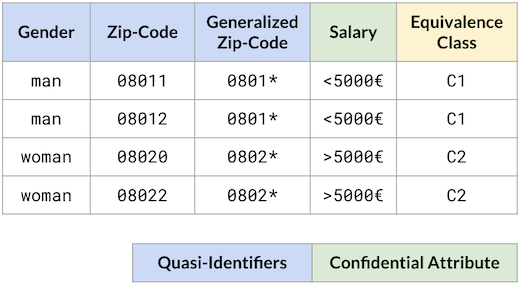

In the above data table, ```Zip-Code``` is generalized to make the dataset 2-anonymous. Note this is applied to all data points.

**[ 0.25 pts ]** Create a function which applies **global recoding** to an attribute in the data upto $n$ digits.

In [ ]:
def global_recoding(data, attribute, n):
    """
    applies global recoding to an attribute in the data for n digits

    Args:
        data (pandas.DataFrame): data for anonymization
        attribute (str): attribute to be recoded
        n (int): number of digits to be recoded

    Returns:
        pandas.DataFrame: globally recoded data
    """
    # your code here
    return data

**[ 0.25 pts ]** Use the function to list all possible ways of 3-anonymizing the dataset given attributes ``BirthDate`` and ``ZipCode``. What is the best way of 3-anonymizing the dataset if we want to preserve maximum information about the health conditions across different zip codes?

In [ ]:
# your code here

**[ Write Answer Here ]**

**[ 1 pt ]** For the best way of $3$-anonymizing the dataset from last question, comment on the sufficiency of $k$-anonymity against **homogeneity** and **background knowledge** attacks aimed at inferring the health condition of patients. If you find $k$-anonymity to be insufficient, you must show quasi-identifier equivalence classes (groups) susceptible to the attacks.

In [ ]:
# your code here

In [ ]:
# your code here

### Microaggregation

Microaggregation aims to achieve $k$-anonymity through clustering. Data points are first grouped into at least *k* clusters, then, for the given quasi-identifier, each data point is changed to new data point representative of the cluster as whole. We usually take the mean to reduce information loss.

How do we partition the data into $k$-clusters?

**Univariate Case**

1.   Sort data by continuous quasi-identifier
2.   Assign first $k$ items to class 1, next k items to class 2, and so on... <br/>

*Note: This is not always optimal

**Multivariate Case**

This is a $k$-partition problem with Minimal Information Loss (NP-Hard)



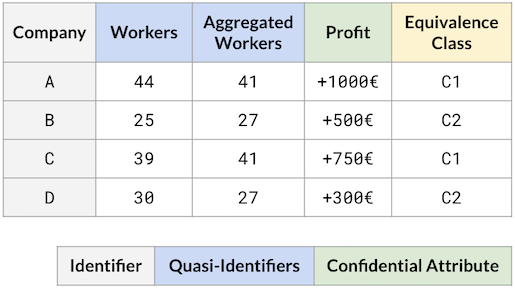

In the above data table, the quasi-identifier ```Workers``` has been aggregated to achieve 2-anonymity.

**[ 1 pt ]** Create a function which microaggregates continuous attributes (``height, weight``) to achieve $k$-anonymity, while minimizing the loss in information across both attributes. Return the best-possible $k$-anonymity and corresponding loss.

**Recommended Approach**: Experiment with a clustering algorithm for $n \leq \frac{|Data|}{k}$ clusters to achieve $k$-anonymity, and use sum of squared errors between original and anonymized data for loss of information.

In [ ]:
def microaggregation(data,attributes,k):
    """
    applies microaggregation to attributes in the data
    to achieve k'-anonymity, k' >= k

    Args:
        data (pandas.DataFrame): data for anonymization
        attributes (list): attributes to be microaggregated
        k (int): lower bound of k-anonymity to achieve

    Returns:
        tuple:
            float: loss of information to achieve k' anonymity
            int: k' corresponding to k'-anonymity achieved
    """
    return loss, observed_k

**[ 0.5 pts ]** Plot the relationship between $k$-anonymity achieved v/s loss of information for $k \in \{2,3,4,...10\}$. What do you observe? In other words, what are the implications of a larger $k$ value?

In [ ]:
# your code here

**[Write Answer Here]**

# L-Diversity

Machanavajjhala, A., Kifer, D., Gehrke, J., & Venkitasubramaniam, M. (2007). L -diversity: Privacy beyond k -anonymity. ACM Transactions on Knowledge Discovery from Data, 1(1), 3. https://doi.org/10.1145/1217299.1217302

A dataset $X$ satisfies $l$-diversity when there exists at least $l$ distinct values of the **confidential attribute** in each equivalence class.

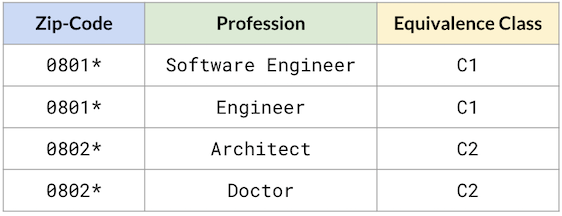

The data table above achieves 2-diversity. There are at least 2 different confidential attributes per combination of quasi-identifiers

## Checking L-Diversity **[ 1 pt ]**

**[ 0.5 pts ]** Create a function which checks whether a dataset is $l$-diverse given a sensitive attribute and quasi-identifiers. If so, return the maximum-$l$ for which the dataset satisfies $l$-diversity.

In [ ]:
def is_l_diverse(data, sensitive, quasi_identifiers):
    """
    checks whether a data is l-diverse for a sensitive
    attribute given quasi-identifiers, and returns the
    maximum l for which the data satisfies l-diversity

    Args:
        data (pandas.DataFrame): data to check l-diversity for
        sensitive (str): sensitive attribute for l-diversity
        quasi_identifiers (list): list of quasi-identifiers

    Returns:
        tuple:
            bool: indicating whether the data is l-diverse
            int: maximum l for which the data satisfies l-diversity
    """
    return True, l

> Answer the following questions for the original dataset, globally recoded dataset.

**[ 0.25 pts ]** Is the dataset $l$-diverse given ``Health Condition`` as sensitive attribute and ``ZipCode, BirthDate`` as quasi-identifiers?

In [ ]:
# your code here

In [ ]:
# your code here

**[ 0.25 pts ]** Is the dataset $l$-diverse given ``Gender`` as sensitive attribute and ``ZipCode, BirthDate`` as quasi-identifiers?

In [ ]:
# your code here

In [ ]:
# your code here

## L-Diversity via Local Suppression **[ 1.5 pts ]**

We can make a dataset $l$-diverse through local suppression. That is, we can selectively remove values from target/problematic records and replace them with an NA or "x" value

**[ 1 pt ]** Create a function to apply local suppression to groups within a $k$-anonymized dataset which violate $l$-diversity given a sensitive attribute, two quasi-identifiers, and $l$. If the same is not feasible, raise an error.


In [ ]:
def local_suppression(data,sensitive,quasi_identifiers,l):
    """
    locally suppresses quasi-identifier equivalence classes
    in anonymized data which violate l-diversity so that the
    overall data satisfies l-diversity

    Args:
        data (pandas.DataFrame): data for local suppression
        sensitive (str): sensitive attribute for l-diversity
        quasi_identifiers (list): quasi-identifiers to suppress
        l (int): l-diversity constraint to satisfy

    Returns:
        pandas.DataFrame: locally suppressed data satisfying l-diversity
    """
    # your code here
    return data

**[ 0.25 pts ]** Using the function, make the globally recoded dataset $2$-diverse for sensitive attribute ``Health Condition`` given quasi_identifiers ``ZipCode``,``BirthDate``, and show the suppressed groups.

In [ ]:
# your code here

In [ ]:
# your code here

**[ 0.25 pts ]** Using the function, make the globally recoded dataset $3$-diverse for sensitive attribute ``Gender`` given quasi_identifiers ``ZipCode``,``BirthDate``, and show the suppressed groups.

In [ ]:
# your code here

In [ ]:
# your code here

## Sufficiency of $k$-anonymity and $l$-diversity **[ 0.5 pts ]**

**[ 0.5 pts ]** Describe one scenario where $k$-anonymity and $l$-diversity would be sufficient for guaranteeing the anonymity of a dataset, and one scenario where they will be insufficient. You may use tables to illustrate your answer.

**[ Answer ]**

#Declaration

<font size="+1">I hereby declare that, except for the code provided by the course instructors, all of my code, report, and figures were produced by myself.</font>

<font color="blue">Your name here</font>